In [75]:
import threading
import queue
import random
import time
import matplotlib.pyplot as plt


"[Data Received] Node 20: {'node_id': 20, 'timestamp': '14:09:46', 'temperature': 25.58, 'cpu_usage': 0.0, 'memory_usage': 67.0, 'network_latency': 99.3}"

In [77]:

# Global Queue for storing sensor data
data_queue = queue.Queue()

# Sensor Node Class
def sensor_node(node_id, data_queue, run_time=10):
    """Simulates a sensor node generating data."""
    start_time = time.time()
    while time.time() - start_time < run_time:
        temperature = random.uniform(15, 35)  # Simulated temperature
        humidity = random.uniform(20, 80)     # Simulated humidity
        pressure = random.uniform(950, 1050)  # Simulated pressure
        timestamp = time.time()
        data = (node_id, timestamp, temperature, humidity, pressure)
        data_queue.put(data)
        print(f"Node {node_id} - Temp: {temperature:.2f}, Humidity: {humidity:.2f}, Pressure: {pressure:.2f}")
        time.sleep(random.uniform(0.5, 2))  # Random delay between readings

# Data Processing Function
def data_processor(data_queue, processed_data, run_time=10):
    """Processes data and detects anomalies."""
    start_time = time.time()
    while time.time() - start_time < run_time or not data_queue.empty():
        if not data_queue.empty():
            data = data_queue.get()
            node_id, timestamp, temperature, humidity, pressure = data
            anomaly = temperature > 30 or humidity < 25  # Simple anomaly detection
            processed_data.append((timestamp, temperature, humidity, pressure, anomaly))
            print(f"Processed Data - Temp: {temperature:.2f}, Humidity: {humidity:.2f}, Pressure: {pressure:.2f}, Anomaly: {anomaly}")
            time.sleep(0.1)

# Initialize nodes and processor
num_nodes = 5
run_time = 10  # Simulation runtime in seconds
processed_data = []

# Start sensor nodes
sensor_threads = []
for i in range(num_nodes):
    thread = threading.Thread(target=sensor_node, args=(i, data_queue, run_time))
    sensor_threads.append(thread)
    thread.start()

# Start data processor
processor_thread = threading.Thread(target=data_processor, args=(data_queue, processed_data, run_time))
processor_thread.start()

# Wait for threads to complete
for thread in sensor_threads:
    thread.join()
processor_thread.join()

# Print final processed data
print("\nFinal Processed Data:")
for data in processed_data:
    print(data)




"[Data Received] Node 15: {'node_id': 15, 'timestamp': '14:09:47', 'temperature': 31.72, 'cpu_usage': 0.0, 'memory_usage': 66.9, 'network_latency': 89.43}"


Final Processed Data:
(1740818435.7143223, 19.30650087869912, 69.65900424161299, 982.3188598214301, False)
(1740818435.717243, 32.98727203556342, 28.266383254621555, 1038.5841332829254, True)
(1740818435.718239, 24.065150392751633, 25.39861113428226, 1032.4708923190258, False)
(1740818435.7189236, 16.50044669801549, 41.883690236097664, 990.4452222659252, False)
(1740818435.7189236, 25.64815590905157, 59.00154900394936, 983.9084162892469, False)


"[Data Received] Node 18: {'node_id': 18, 'timestamp': '14:09:47', 'temperature': 78.84, 'cpu_usage': 0.0, 'memory_usage': 66.9, 'network_latency': 34.87}"

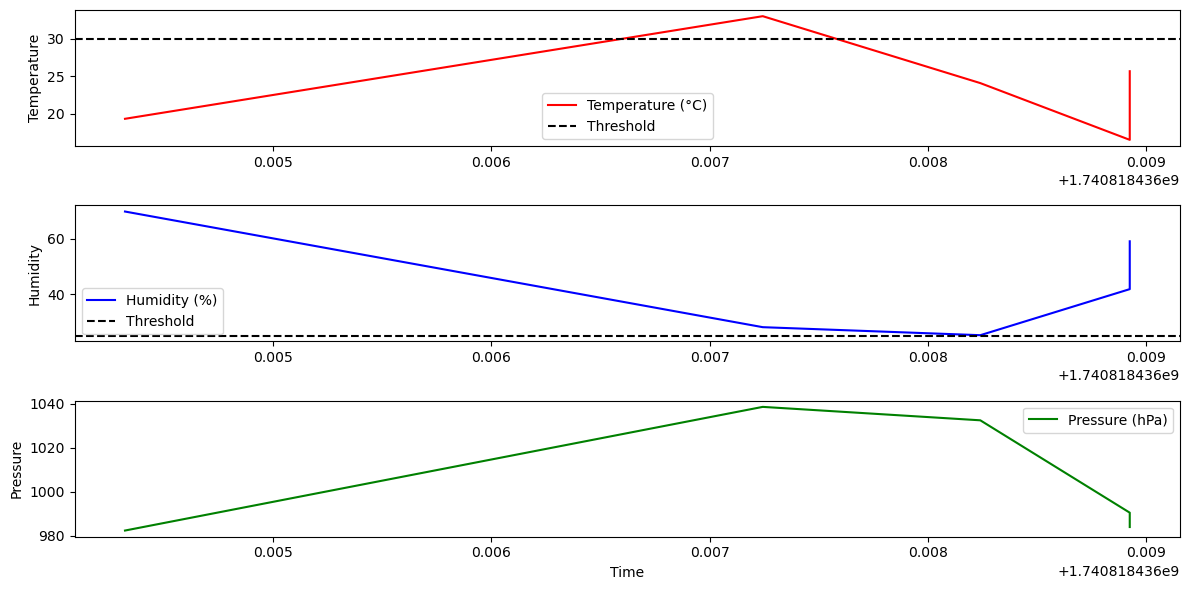

In [78]:
# Data Visualization
def plot_results(processed_data):
    timestamps = [data[0] for data in processed_data]
    temperatures = [data[1] for data in processed_data]
    humidities = [data[2] for data in processed_data]
    pressures = [data[3] for data in processed_data]

    plt.figure(figsize=(12, 6))
    plt.subplot(3, 1, 1)
    plt.plot(timestamps, temperatures, label='Temperature (°C)', color='red')
    plt.axhline(y=30, color='black', linestyle='--', label='Threshold')
    plt.legend()
    plt.ylabel("Temperature")

    plt.subplot(3, 1, 2)
    plt.plot(timestamps, humidities, label='Humidity (%)', color='blue')
    plt.axhline(y=25, color='black', linestyle='--', label='Threshold')
    plt.legend()
    plt.ylabel("Humidity")

    plt.subplot(3, 1, 3)
    plt.plot(timestamps, pressures, label='Pressure (hPa)', color='green')
    plt.legend()
    plt.xlabel("Time")
    plt.ylabel("Pressure")

    plt.tight_layout()
    plt.show()

# Plot results
plot_results(processed_data)

In [79]:
import threading
import queue
import random
import time

# Define the Data Queue
data_queue = queue.Queue()

class Node(threading.Thread):
    def __init__(self, node_id):
        super().__init__()
        self.node_id = node_id
        self.running = True
    
    def generate_data(self):
        """Simulate sensor data generation"""
        return {
            'node_id': self.node_id,
            'temperature': round(random.uniform(20.0, 35.0), 2),
            'humidity': round(random.uniform(30.0, 70.0), 2),
            'timestamp': time.time()
        }
    
    def run(self):
        while self.running:
            data = self.generate_data()
            data_queue.put(data)  # Send data to the central queue
            print(f"Node {self.node_id} generated data: {data}")
            time.sleep(random.uniform(0.5, 2))  # Simulate real-time interval
    
    def stop(self):
        self.running = False

class DataProcessor(threading.Thread):
    def __init__(self):
        super().__init__()
        self.running = True
    
    def process_data(self, data):
        """Process received data and flag anomalies"""
        if data['temperature'] > 30:
            print(f"ALERT: High temperature detected at Node {data['node_id']}: {data['temperature']}°C")
        if data['humidity'] < 35:
            print(f"WARNING: Low humidity detected at Node {data['node_id']}: {data['humidity']}%")
    
    def run(self):
        while self.running:
            if not data_queue.empty():
                data = data_queue.get()
                self.process_data(data)
            time.sleep(0.1)  # Allow other threads to run
    
    def stop(self):
        self.running = False

if __name__ == "__main__":
    # Initialize Nodes
    num_nodes = 5  # Simulate 5 sensors
    nodes = [Node(i) for i in range(num_nodes)]
    processor = DataProcessor()
    
    # Start the nodes and processor
    for node in nodes:
        node.start()
    processor.start()
    
    # Run for 20 seconds and then stop
    time.sleep(20)
    for node in nodes:
        node.stop()
    processor.stop()
    
    # Wait for threads to finish
    for node in nodes:
        node.join()
    processor.join()
    
    print("Monitoring system stopped.")


"[Data Received] Node 17: {'node_id': 17, 'timestamp': '14:09:48', 'temperature': 54.52, 'cpu_usage': 0.0, 'memory_usage': 66.9, 'network_latency': 96.13}"

Monitoring system stopped.


In [ ]:
import tkinter as tk
from tkinter import ttk
import random
import threading
import queue
import time

# Create a queue for real-time data processing
data_queue = queue.Queue()
running = True  # Flag to control data generation

# Function to generate random sensor data
def generate_sensor_data(sensor_id):
    while running:
        temperature = round(random.uniform(20, 40), 2)
        humidity = round(random.uniform(30, 70), 2)
        data_queue.put((sensor_id, temperature, humidity))
        time.sleep(random.uniform(1, 3))

# Function to process data
def process_data():
    while True:
        if not data_queue.empty():
            sensor_id, temperature, humidity = data_queue.get()
            update_gui(sensor_id, temperature, humidity)
        time.sleep(1)

# GUI Update Function
def update_gui(sensor_id, temperature, humidity):
    tree.insert("", "end", values=(sensor_id, temperature, humidity))
    
    # Change status label color based on temperature
    if temperature > 35:
        status_label.config(text=f"🔥 Warning! High Temperature at Sensor {sensor_id}", fg="red", bg="black")
    elif temperature < 22:
        status_label.config(text=f"❄️ Low Temperature Alert at Sensor {sensor_id}", fg="blue", bg="black")
    else:
        status_label.config(text="✅ System Operating Normally", fg="green", bg="black")

# Function to start generating data
def start_data():
    global running
    running = True
    for i in range(1, 6):
        threading.Thread(target=generate_sensor_data, args=(i,), daemon=True).start()
    status_label.config(text="📡 Sensors Activated!", fg="yellow")

# Function to stop generating data
def stop_data():
    global running
    running = False
    status_label.config(text="⚠️ Sensors Stopped!", fg="orange")

# Function to clear table data
def clear_data():
    for row in tree.get_children():
        tree.delete(row)
    status_label.config(text="🗑 Data Cleared!", fg="white")

# Start GUI Application
root = tk.Tk()
root.title("🌍 Decentralized IMS Monitor")
root.geometry("700x450")
root.configure(bg="#1c1c1c")

# Styling
style = ttk.Style()
style.configure("Treeview", background="#3c4048", foreground="white", fieldbackground="#3c4048")
style.configure("Treeview.Heading", font=("Arial", 12, "bold"))
style.configure("TButton", font=("Arial", 10, "bold"), padding=5, background="#ffcc00")

# Table for Displaying Data
tree = ttk.Treeview(root, columns=("Sensor ID", "Temperature (°C)", "Humidity (%)"), show="headings")
tree.heading("Sensor ID", text="🔎 Sensor ID")
tree.heading("Temperature (°C)", text="🌡 Temperature (°C)")
tree.heading("Humidity (%)", text="💧 Humidity (%)")
tree.pack(pady=10, padx=10, fill=tk.BOTH, expand=True)

# Status Label
status_label = tk.Label(root, text="🔄 System Initializing...", font=("Arial", 12, "bold"), bg="black", fg="yellow")
status_label.pack(pady=5, fill=tk.X)

# Button Frame
button_frame = tk.Frame(root, bg="#1c1c1c")
button_frame.pack(pady=10)

start_btn = tk.Button(button_frame, text="▶ Start", command=start_data, font=("Arial", 12, "bold"), bg="green", fg="white", width=10)
start_btn.grid(row=0, column=0, padx=10)

stop_btn = tk.Button(button_frame, text="⏹ Stop", command=stop_data, font=("Arial", 12, "bold"), bg="red", fg="white", width=10)
stop_btn.grid(row=0, column=1, padx=10)

clear_btn = tk.Button(button_frame, text="🗑 Clear", command=clear_data, font=("Arial", 12, "bold"), bg="blue", fg="white", width=10)
clear_btn.grid(row=0, column=2, padx=10)

# Start Data Processing Thread
threading.Thread(target=process_data, daemon=True).start()

# Run GUI
root.mainloop()


In [ ]:
import threading
import time
import psutil
import random
from queue import Queue
import tkinter as tk
from tkinter import scrolledtext, ttk

# Simulating decentralized monitoring nodes with real-time data
class MonitoringNode(threading.Thread):
    def __init__(self, node_id, data_queue):
        super().__init__()
        self.node_id = node_id
        self.data_queue = data_queue
        self.running = True

    def run(self):
        while self.running:
            data = {
                'node_id': self.node_id,
                'timestamp': time.strftime("%H:%M:%S"),
                'temperature': round(random.uniform(20.0, 80.0), 2),
                'cpu_usage': psutil.cpu_percent(interval=None),  
                'memory_usage': psutil.virtual_memory().percent,
                'network_latency': round(random.uniform(10, 100), 2)
            }
            self.data_queue.put(data)
            time.sleep(0.5)  

    def stop(self):
        self.running = False

# Centralized Data Aggregator
class DataAggregator:
    def __init__(self, num_nodes):
        self.data_queue = Queue()
        self.nodes = [MonitoringNode(i, self.data_queue) for i in range(1, num_nodes + 1)]
        self.collected_data = []

    def start(self):
        for node in self.nodes:
            node.start()

    def stop(self):
        for node in self.nodes:
            node.stop()
            node.join()

    def get_data(self):
        while not self.data_queue.empty():
            data = self.data_queue.get()
            self.collected_data.append(data)
            return data
        return None

    def get_summary(self):
        if not self.collected_data:
            return "No data collected."
        avg_temp = sum(d['temperature'] for d in self.collected_data) / len(self.collected_data)
        avg_cpu = sum(d['cpu_usage'] for d in self.collected_data) / len(self.collected_data)
        avg_memory = sum(d['memory_usage'] for d in self.collected_data) / len(self.collected_data)
        avg_latency = sum(d['network_latency'] for d in self.collected_data) / len(self.collected_data)
        return (f"Monitoring Summary:\n\n"
                f"Avg Temperature: {avg_temp:.2f}°C\n"
                f"Avg CPU Usage: {avg_cpu:.2f}%\n"
                f"Avg Memory Usage: {avg_memory:.2f}%\n"
                f"Avg Network Latency: {avg_latency:.2f}ms\n")

    def detect_system(self):
        unique_nodes = len(set(d['node_id'] for d in self.collected_data))
        if unique_nodes >= 3:
            return "✔ System is Decentralized!\nMultiple nodes detected, confirming decentralization."
        else:
            return "❌ System is NOT Decentralized!\nFewer than 3 nodes detected."

# GUI for Monitoring
class MonitoringGUI:
    def __init__(self, root, aggregator):
        self.root = root
        self.aggregator = aggregator
        self.root.title("🔍 Decentralized Monitoring Platform")
        self.root.geometry("900x600")
        self.root.configure(bg="#20232A")

        # Title
        self.label = tk.Label(root, text="📡 Infrastructure Monitoring Dashboard", font=("Arial", 16, "bold"), fg="white", bg="#20232A")
        self.label.pack(pady=10)

        # Text Area for Logs
        self.text_area = scrolledtext.ScrolledText(root, width=100, height=15, bg="white", fg="black", font=("Arial", 10))
        self.text_area.pack(pady=10)

        # Buttons Frame
        self.button_frame = tk.Frame(root, bg="#20232A")
        self.button_frame.pack(pady=5)

        self.start_button = ttk.Button(self.button_frame, text="🚀 Start Monitoring", command=self.start_monitoring, style="TButton")
        self.start_button.grid(row=0, column=0, padx=10)

        self.stop_button = ttk.Button(self.button_frame, text="🛑 Stop Monitoring", command=self.stop_monitoring, state=tk.DISABLED, style="TButton")
        self.stop_button.grid(row=0, column=1, padx=10)

        self.show_result_button = ttk.Button(self.button_frame, text="📊 Show Result", command=self.show_results, state=tk.DISABLED, style="TButton")
        self.show_result_button.grid(row=0, column=2, padx=10)

        self.running = False

        # Result Section
        self.result_frame = tk.Frame(root, bg="#34495E", pady=10, padx=10)
        self.result_frame.pack(fill=tk.BOTH, expand=True, pady=10)

        # Smaller Font Size for Results
        self.result_label = tk.Label(self.result_frame, text="📢 Results will appear here!", font=("Arial", 9), fg="white", bg="#34495E", justify="left", wraplength=850)
        self.result_label.pack(pady=10)

        # Button Styling
        self.style = ttk.Style()
        self.style.configure("TButton", font=("Arial", 12), padding=6)

    def start_monitoring(self):
        self.running = True
        self.start_button.config(state=tk.DISABLED)
        self.stop_button.config(state=tk.NORMAL)
        self.show_result_button.config(state=tk.DISABLED)
        self.aggregator.start()
        self.update_display()

    def stop_monitoring(self):
        self.running = False
        self.start_button.config(state=tk.NORMAL)
        self.stop_button.config(state=tk.DISABLED)
        self.show_result_button.config(state=tk.NORMAL)  # Enable result button
        self.aggregator.stop()

    def update_display(self):
        if self.running:
            while not self.aggregator.data_queue.empty():  
                data = self.aggregator.get_data()
                if data:
                    self.text_area.insert(tk.END, f"🔹 Node {data['node_id']}:\n"
                                                  f"   🕒 Timestamp: {data['timestamp']}\n"
                                                  f"   🌡️ Temperature: {data['temperature']}°C\n"
                                                  f"   💻 CPU Usage: {data['cpu_usage']}%\n"
                                                  f"   📊 Memory Usage: {data['memory_usage']}%\n"
                                                  f"   🌐 Network Latency: {data['network_latency']}ms\n\n")
                    self.text_area.yview(tk.END)
            self.root.after(500, self.update_display)  

    def show_results(self):
        summary = self.aggregator.get_summary()
        detection_result = self.aggregator.detect_system()

        # Display results inside the GUI with smaller font
        self.result_label.config(text=f"{summary}\n\n{detection_result}", font=("Arial", 9), fg="white", bg="#2ECC71" if "✔" in detection_result else "#E74C3C")

if __name__ == "__main__":
    num_nodes = 20  
    aggregator = DataAggregator(num_nodes)

    root = tk.Tk()
    gui = MonitoringGUI(root, aggregator)
    root.mainloop()
